# Unidad 5 — Complejidad Algorítmica

La complejidad algorítmica nos permite predecir cómo escala el rendimiento de un algoritmo
cuando crece el tamaño de la entrada. La notación Big O es el estándar para expresarla.

## Objetivos de aprendizaje
- [ ] Reconocer las complejidades: O(1), O(log n), O(n), O(n log n), O(n²), O(2^n)
- [ ] Medir tiempos reales con `time` y `timeit`
- [ ] Comparar búsqueda lineal vs binaria
- [ ] Comparar Bubble Sort vs sorted() de Python
- [ ] Comparar Fibonacci recursivo, iterativo y con memoización


In [ ]:
# ─── Setup ───
import time
import random
from functools import lru_cache
print("Unidad 5 — Complejidad Algorítmica")


## 1. Notaciones Big O

La notación Big O describe el **peor caso** del crecimiento de tiempo/espacio en función del tamaño n.

| Notación | Nombre | Ejemplo |
|---|---|---|
| O(1) | Constante | Acceso a lista por índice |
| O(log n) | Logarítmica | Búsqueda binaria |
| O(n) | Lineal | Búsqueda secuencial |
| O(n log n) | Linealítmica | Merge sort, Timsort |
| O(n²) | Cuadrática | Bubble sort, doble for |
| O(2^n) | Exponencial | Fibonacci recursivo sin caché |

Regla de oro: **O(1) > O(log n) > O(n) > O(n log n) > O(n²) > O(2^n)**


In [ ]:
# ─── Demostración visual de Big O ───
import time

def medir_tiempo(func, *args):
    inicio = time.perf_counter()
    resultado = func(*args)
    fin = time.perf_counter()
    return resultado, (fin - inicio) * 1000

# O(1) — acceso por índice
lista_grande = list(range(1_000_000))
def acceso_o1(lst):
    return lst[500_000]  # siempre la misma operación sin importar el tamaño

# O(n) — búsqueda lineal
def buscar_lineal(lst, objetivo):
    for i, elem in enumerate(lst):
        if elem == objetivo:
            return i
    return -1

# O(n²) — nested loop
def doble_bucle(n):
    contador = 0
    for i in range(n):
        for j in range(n):
            contador += 1
    return contador

print("Mediciones de tiempo:")
_, t1 = medir_tiempo(acceso_o1, lista_grande)
print(f"  O(1)  acceso por índice (n=1M): {t1:.4f} ms")

_, t2 = medir_tiempo(buscar_lineal, lista_grande, 999_999)
print(f"  O(n)  búsqueda lineal (n=1M):   {t2:.2f} ms")

_, t3 = medir_tiempo(doble_bucle, 1000)
print(f"  O(n²) doble bucle (n=1000):     {t3:.2f} ms")


Mediciones de tiempo:
  O(1)  acceso por índice (n=1M): 0.0020 ms
  O(n)  búsqueda lineal (n=1M):   55.76 ms
  O(n²) doble bucle (n=1000):     42.64 ms


## 2. Búsqueda lineal vs búsqueda binaria

- **Búsqueda lineal O(n)**: revisa cada elemento de izquierda a derecha
- **Búsqueda binaria O(log n)**: divide el espacio a la mitad en cada paso (requiere lista ordenada)

Para n = 1,000,000: lineal necesita hasta 1,000,000 comparaciones; binaria como máximo 20.


In [ ]:
# ─── Búsqueda lineal ───
def busqueda_lineal(lista, objetivo):
    for i, elemento in enumerate(lista):
        if elemento == objetivo:
            return i
    return -1

# ─── Búsqueda binaria ───
def busqueda_binaria(lista, objetivo):
    izquierda, derecha = 0, len(lista) - 1
    comparaciones = 0
    while izquierda <= derecha:
        comparaciones += 1
        medio = (izquierda + derecha) // 2
        if lista[medio] == objetivo:
            return medio, comparaciones
        elif lista[medio] < objetivo:
            izquierda = medio + 1
        else:
            derecha = medio - 1
    return -1, comparaciones

# ─── Comparación ───
n = 1_000_000
datos = list(range(n))
objetivo = 876_543

inicio = time.perf_counter()
idx_lineal = busqueda_lineal(datos, objetivo)
t_lineal = (time.perf_counter() - inicio) * 1000

inicio = time.perf_counter()
idx_bin, comparaciones = busqueda_binaria(datos, objetivo)
t_binaria = (time.perf_counter() - inicio) * 1000

print(f"Lista de {n:,} elementos, buscando {objetivo:,}")
print(f"\nBúsqueda lineal:  {t_lineal:.3f} ms  (índice={idx_lineal})")
print(f"Búsqueda binaria: {t_binaria:.4f} ms  (índice={idx_bin}, comparaciones={comparaciones})")
print(f"\nBinaria es {t_lineal/t_binaria:.0f}x más rápida")
print(f"log₂({n:,}) ≈ {n.bit_length()} → máximo {n.bit_length()} comparaciones en binaria")


Lista de 1,000,000 elementos, buscando 876,543

Búsqueda lineal:  53.124 ms  (índice=876543)
Búsqueda binaria: 0.0995 ms  (índice=876543, comparaciones=20)

Binaria es 534x más rápida
log₂(1,000,000) ≈ 20 → máximo 20 comparaciones en binaria


## 3. Bubble Sort O(n²) vs sorted() O(n log n)

Bubble sort es el algoritmo de ordenación más simple pero el menos eficiente.
Python usa **Timsort** (híbrido de Merge Sort + Insertion Sort) que es O(n log n).


In [ ]:
import time
import random

# ─── Bubble Sort ───
def bubble_sort(lista):
    lst = lista.copy()
    n = len(lst)
    for i in range(n):
        for j in range(0, n - i - 1):
            if lst[j] > lst[j + 1]:
                lst[j], lst[j + 1] = lst[j + 1], lst[j]
    return lst

# ─── Comparar tiempos ───
print(f"{'n':>8} | {'Bubble Sort':>12} | {'sorted()':>10} | {'Factor':>8}")
print("-" * 48)

for n in [100, 500, 1000, 2000, 5000]:
    datos = [random.randint(0, 10000) for _ in range(n)]

    inicio = time.perf_counter()
    bubble_sort(datos)
    t_bubble = (time.perf_counter() - inicio) * 1000

    inicio = time.perf_counter()
    sorted(datos)
    t_sorted = (time.perf_counter() - inicio) * 1000

    factor = t_bubble / t_sorted if t_sorted > 0 else float("inf")
    print(f"{n:>8} | {t_bubble:>10.2f}ms | {t_sorted:>8.4f}ms | {factor:>7.0f}x")


       n |  Bubble Sort |   sorted() |   Factor
------------------------------------------------
     100 |       0.66ms |   0.0116ms |      57x
     500 |      10.66ms |   0.0592ms |     180x
    1000 |      55.86ms |   0.1735ms |     322x
    2000 |     220.12ms |   0.3134ms |     702x
    5000 |    1331.67ms |   0.7545ms |    1765x


## 4. Fibonacci: recursivo O(2^n) vs iterativo O(n) vs memoización O(n)

- **Recursivo sin caché**: recalcula los mismos valores exponencialmente
- **Iterativo**: calcula cada valor una sola vez
- **@lru_cache**: memoización automática — almacena resultados previamente calculados


In [ ]:
from functools import lru_cache
import time

# ─── Fibonacci recursivo (O(2^n)) ───
def fib_recursivo(n):
    if n <= 1:
        return n
    return fib_recursivo(n - 1) + fib_recursivo(n - 2)

# ─── Fibonacci iterativo (O(n)) ───
def fib_iterativo(n):
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

# ─── Fibonacci con memoización (O(n)) ───
@lru_cache(maxsize=None)
def fib_memo(n):
    if n <= 1:
        return n
    return fib_memo(n - 1) + fib_memo(n - 2)

# ─── Comparar tiempos ───
print(f"{'n':>5} | {'Recursivo':>12} | {'Iterativo':>12} | {'Memoizado':>12}")
print("-" * 52)

for n in [10, 20, 25, 30, 35]:
    # Recursivo (solo hasta 35 para no tardar demasiado)
    inicio = time.perf_counter()
    r = fib_recursivo(n)
    t_rec = (time.perf_counter() - inicio) * 1000

    inicio = time.perf_counter()
    fib_iterativo(n)
    t_ite = (time.perf_counter() - inicio) * 1000

    inicio = time.perf_counter()
    fib_memo(n)
    t_mem = (time.perf_counter() - inicio) * 1000

    print(f"{n:>5} | {t_rec:>10.3f}ms | {t_ite:>10.4f}ms | {t_mem:>10.4f}ms")

print(f"\nfib(35) = {fib_iterativo(35)}")

    n |    Recursivo |    Iterativo |    Memoizado
----------------------------------------------------
   10 |      0.014ms |     0.0026ms |     0.0057ms
   20 |      1.352ms |     0.0026ms |     0.0043ms
   25 |     14.915ms |     0.0037ms |     0.0070ms
   30 |    167.691ms |     0.0081ms |     0.0084ms
   35 |   2289.140ms |     0.0075ms |     0.0091ms

fib(35) = 9227465


---
## Ejercicios

### 🟢 Ejercicio 1 — Identificar complejidad
Identificar la complejidad Big O de cada fragmento de código.


In [ ]:
# 🎯 EJERCICIO 1: Identificar la complejidad de cada función
# Analizá mentalmente cada función y escribí su complejidad en el comentario

def funcion_a(lista):
    return lista[0]  # O(1) constante

def funcion_b(lista):
    for elem in lista:
        print(elem)  # O(n) lineal  Si la lista crece, el tiempo de ejecución crece en la misma proporción

def funcion_c(n):
    while n > 1:
        n = n // 2  # O(Log n) logaritmica
        #En cada iteración del bucle while, el valor de n se divide por la mitad (n // 2). Este patrón de "dividir para conquistar" reduce drásticamente el número de pasos necesarios para llegar al 1

def funcion_d(lista):
    for i in lista:
        for j in lista:
            print(i, j)  # O(n^2) cuadratica
    #es un bucle anidado. Por cada elemento en la lista, el #programa recorre la lista entera de nuevo ejecutandose N x N veces

def funcion_e(n):
    if n <= 0:
        return 1
    return funcion_e(n-1) + funcion_e(n-1)  # O(2^n) Esta es una función recursiva donde cada llamada genera dos nuevas llamadas adicionales

# Resultados esperados: O(1), O(n), O(log n), O(n²), O(2^n)


### 🟡 Ejercicio 2 — Comparar suma para 1M elementos
Comparar: suma con for loop vs sum() vs numpy.sum() para 1,000,000 elementos.


In [ ]:
# 🎯 EJERCICIO 2: Comparar formas de sumar 1M elementos
import time
try:
    import numpy as np
    numpy_disponible = True
except ImportError:
    numpy_disponible = False

n=1_000_1000
numeros = list(range(1_000_000))

# Tu código aquí: medir tiempo de cada variante y comparar
# ─── Comparación ───

#sumar con FOR LOOP
inicio = time.time()
suma_for = 0
for num in numeros:
    suma_for += num
fin = time.time()
print(f"For Loop: {fin - inicio: .6f} segundos")

#SUMAR CON sum()
inicio = time.time()
suma_sum = sum(numeros)
fin = time.time()
print(f"Built-in sum(): {fin - inicio: .6f} segundos")

#suma con numpy.sum()
if numpy_disponible:
    numeros_np = np.array(numeros)
    inicio = time.time()
    suma_np = np.sum(numeros_np)
    fin = time.time()
    print(f"numpy.sum(): {fin - inicio: .6f} segundos")
else:
    print("numpy no disponible.")


# Resultado esperado (tiempos aproximados):
# for loop: ~50-100ms
# sum():    ~5-15ms
# np.sum(): ~1-5ms (si numpy disponible)


For Loop:  0.111830 segundos
Built-in sum():  0.014482 segundos
numpy.sum():  0.000885 segundos


### 🟡 Ejercicio 3 — Búsqueda binaria desde cero
Implementar búsqueda binaria en una lista ordenada.


In [ ]:
# 🎯 EJERCICIO 3: Implementar búsqueda binaria
def busqueda_binaria_propia(lista_ordenada, objetivo):
    # Tu código aquí
    pass
    izquierda, derecha = 0, len(lista_ordenada) - 1
    comparaciones = 0
    while izquierda <= derecha:
        comparaciones += 1
        medio = (izquierda + derecha) // 2
        if lista_ordenada[medio] == objetivo:
            return medio, comparaciones
        elif lista_ordenada[medio] < objetivo:
            izquierda = medio + 1
        else:
            derecha = medio - 1
    return -1, comparaciones

# Pruebas:
numeros = list(range(0, 200, 2))  # [0, 2, 4, 6, ..., 198]
print(busqueda_binaria_propia(numeros, 128))  # → índice 64
print(busqueda_binaria_propia(numeros, 99))   # → -1 (no existe)


(64, 5)
(-1, 6)


### 🔴 Ejercicio 4 — Bubble sort vs sorted()
Comparar tiempos de Bubble Sort vs sorted() para n = 100, 1000, 5000.


In [ ]:
# 🎯 EJERCICIO 4: Comparación de ordenamiento
import random, time

def mi_bubble_sort(lista):
    # Tu código aquí
    pass
    lst = lista.copy()
    n = len(lst)
    for i in range(n):
        for j in range(0, n - i - 1):
            if lst[j] > lst[j + 1]:
                lst[j], lst[j + 1] = lst[j + 1], lst[j]
    return lst

# Tu código aquí: medir y comparar tiempos para n = 100, 1000, 5000
# ─── Comparar tiempos ───
print(f"{'n':>8} | {'Bubble Sort':>12} | {'sorted()':>10} | {'Factor':>8}")
print("-" * 48)

for n in [100, 1000, 3000]:
    datos = [random.randint(0, 10000) for _ in range(n)]

    inicio = time.perf_counter()
    bubble_sort(datos)
    t_bubble = (time.perf_counter() - inicio) * 1000

    inicio = time.perf_counter()
    sorted(datos)
    t_sorted = (time.perf_counter() - inicio) * 1000

    factor = t_bubble / t_sorted if t_sorted > 0 else float("inf")
    print(f"{n:>8} | {t_bubble:>10.2f}ms | {t_sorted:>8.4f}ms | {factor:>7.0f}x")


       n |  Bubble Sort |   sorted() |   Factor
------------------------------------------------
     100 |       0.63ms |   0.0111ms |      57x
    1000 |      50.95ms |   0.1266ms |     403x
    3000 |     480.24ms |   0.4505ms |    1066x


### 🔴 Ejercicio 5 — Comparar 3 versiones de Fibonacci
Comparar Fibonacci recursivo (O(2^n)), iterativo (O(n)) y con @lru_cache.


In [ ]:
# 🎯 EJERCICIO 5: Las 3 versiones de Fibonacci
from functools import lru_cache
import time

# Tu código aquí: implementar las 3 versiones y comparar tiempos para n=10,20,30
# ─── Fibonacci recursivo (O(2^n)) ───
def fib_recursivo(n):
    if n <= 1:
        return n
    return fib_recursivo(n - 1) + fib_recursivo(n - 2)

# ─── Fibonacci iterativo (O(n)) ───
def fib_iterativo(n):
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

# ─── Fibonacci con memoización (O(n)) ───
@lru_cache(maxsize=None)
def fib_memo(n):
    if n <= 1:
        return n
    return fib_memo(n - 1) + fib_memo(n - 2)

# ─── Comparar tiempos ───
print(f"{'n':>5} | {'Recursivo':>12} | {'Iterativo':>12} | {'Memoizado':>12}")
print("-" * 52)

for n in [10, 20, 25, 30, 35]:
    # Recursivo (solo hasta 35 para no tardar demasiado)
    inicio = time.perf_counter()
    r = fib_recursivo(n)
    t_rec = (time.perf_counter() - inicio) * 1000

    inicio = time.perf_counter()
    fib_iterativo(n)
    t_ite = (time.perf_counter() - inicio) * 1000

    inicio = time.perf_counter()
    fib_memo(n)
    t_mem = (time.perf_counter() - inicio) * 1000

    print(f"{n:>5} | {t_rec:>10.3f}ms | {t_ite:>10.4f}ms | {t_mem:>10.4f}ms")

print(f"\nfib(35) = {fib_iterativo(35)}")

    n |    Recursivo |    Iterativo |    Memoizado
----------------------------------------------------
   10 |      0.015ms |     0.0029ms |     0.0060ms
   20 |      1.629ms |     0.0052ms |     0.0075ms
   25 |     16.423ms |     0.0056ms |     0.0111ms
   30 |    165.308ms |     0.0085ms |     0.0089ms
   35 |   1869.790ms |     0.0079ms |     0.0090ms

fib(35) = 9227465


---
## Mini-proyecto: Comparador de algoritmos de búsqueda

**Escenario:** Comparar búsqueda lineal vs binaria para listas de distintos tamaños.
Si matplotlib está disponible, graficar el tiempo en función de n.


           n |  Lineal (ms) |  Binaria (ms) |   Factor
-------------------------------------------------------
       1,000 |        0.033 |        0.0021 |      16x
      10,000 |        0.164 |        0.0022 |      75x
     100,000 |        5.557 |        0.0037 |    1521x
     500,000 |       17.975 |        0.0040 |    4520x
   1,000,000 |       21.373 |        0.0041 |    5212x


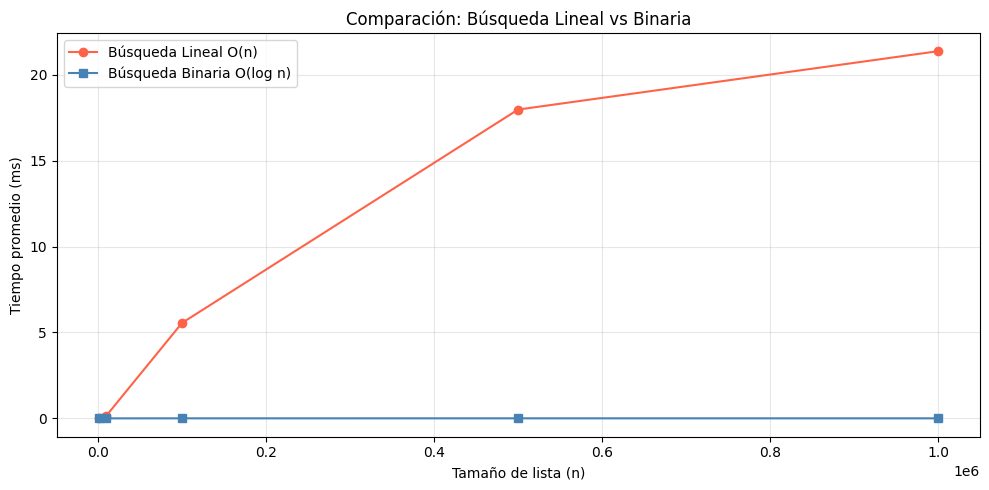

Gráfico generado


In [ ]:
# ─── Mini-proyecto: Comparador de búsqueda lineal vs binaria ───
import time
import random

def busqueda_lineal_v2(lista, objetivo):
    for i, elem in enumerate(lista):
        if elem == objetivo:
            return i
    return -1

def busqueda_binaria_v2(lista, objetivo):
    izq, der = 0, len(lista) - 1
    while izq <= der:
        medio = (izq + der) // 2
        if lista[medio] == objetivo:
            return medio
        elif lista[medio] < objetivo:
            izq = medio + 1
        else:
            der = medio - 1
    return -1

# ─── Benchmark ───
tamaños = [1_000, 10_000, 100_000, 500_000, 1_000_000]
print(f"{'n':>12} | {'Lineal (ms)':>12} | {'Binaria (ms)':>13} | {'Factor':>8}")
print("-" * 55)

tiempos_lineal = []
tiempos_binario = []

for n in tamaños:
    datos = sorted(random.sample(range(n * 2), n))
    objetivo = datos[random.randint(0, n - 1)]  # elemento que existe

    repeticiones = 10
    inicio = time.perf_counter()
    for _ in range(repeticiones):
        busqueda_lineal_v2(datos, objetivo)
    t_lin = (time.perf_counter() - inicio) / repeticiones * 1000

    inicio = time.perf_counter()
    for _ in range(repeticiones):
        busqueda_binaria_v2(datos, objetivo)
    t_bin = (time.perf_counter() - inicio) / repeticiones * 1000

    tiempos_lineal.append(t_lin)
    tiempos_binario.append(t_bin)
    factor = t_lin / t_bin if t_bin > 0 else float("inf")
    print(f"{n:>12,} | {t_lin:>12.3f} | {t_bin:>13.4f} | {factor:>7.0f}x")

# ─── Graficar (si matplotlib disponible) ───
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(tamaños, tiempos_lineal, "o-", label="Búsqueda Lineal O(n)", color="tomato")
    ax.plot(tamaños, tiempos_binario, "s-", label="Búsqueda Binaria O(log n)", color="steelblue")
    ax.set_xlabel("Tamaño de lista (n)")
    ax.set_ylabel("Tiempo promedio (ms)")
    ax.set_title("Comparación: Búsqueda Lineal vs Binaria")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("Gráfico generado")
except ImportError:
    print("\nmatplotlib no disponible — instalar con: pip install matplotlib")


---
## Desafío extra 🔴

Implementar y comparar **Merge Sort** (O(n log n)) vs **Bubble Sort** (O(n²)).
- Implementar Merge Sort recursivo desde cero
- Medir ambos para n = 100, 1000, 5000, 10000
- Graficar si matplotlib disponible
- Calcular la relación teórica n²/(n log₂n) y compararla con la relación medida


In [ ]:
# 🔴 Desafío: Merge Sort vs Bubble Sort
import time, random, math

def merge_sort(lista):
    if len(lista) <= 1:
        return lista
    # divido
    medio = len(lista) // 2
    izquierda = merge_sort(lista[:medio])
    derecha = merge_sort(lista[medio:])
    # combino
    return merge(izquierda, derecha)

def merge(izquierda, derecha):
    resultado = []
    i, j = 0, 0
    while i < len(izquierda) and j < len(derecha):
        if izquierda[i] < derecha[j]:
            resultado.append(izquierda[i])
            i += 1
        else:
            resultado.append(derecha[j])
            j += 1

    resultado.extend(izquierda[i:])
    resultado.extend(derecha[j:])
    return resultado


def bubble_sort_simple(lista):
    lst = lista.copy()
    n = len(lst)
    for i in range(n):
        for j in range(n - i - 1):
            if lst[j] > lst[j+1]:
                lst[j], lst[j+1] = lst[j+1], lst[j]
    return lst

# Tu código aquí: benchmark y gráfico
import time, random, math
tamaños = [100, 1000, 5000, 10000]
resultados_bubble = [] # Corrected variable name
resultados_merge = []
for n in tamaños:
    lista_grande = [random.randint(0, 10000) for _ in range(n)]
    # Medir Bubble Sort
    inicio = time.time()
    bubble_sort_simple(lista_grande) # Corrected variable name
    resultados_bubble.append(time.time() - inicio)

    # Medir Merge Sort
    inicio = time.time()
    merge_sort(lista_grande) # Corrected variable name
    resultados_merge.append(time.time() - inicio)

    # Cálculo de relación teórica: n^2 / (n * log2(n)) -> n / log2(n)
    relacion_teorica = (n**2) / (n * math.log2(n)) if math.log2(n) != 0 else float('inf') # Simplified to n / log2(n) and added check for log2(n) == 0
    relacion_real = resultados_bubble[-1] / resultados_merge[-1] if resultados_merge[-1] != 0 else float('inf')

    print(f"N={n} | Relación Teórica: {relacion_teorica:.2f} | Relación Real: {relacion_real:.2f}")


N=100 | Relación Teórica: 15.05 | Relación Real: 2.42
N=1000 | Relación Teórica: 100.34 | Relación Real: 26.94
N=5000 | Relación Teórica: 406.91 | Relación Real: 108.04
N=10000 | Relación Teórica: 752.57 | Relación Real: 131.48


---
## Resumen de conceptos

| Complejidad | Nombre | Crecimiento para n=1M |
|---|---|---|
| O(1) | Constante | 1 operación |
| O(log n) | Logarítmica | ~20 operaciones |
| O(n) | Lineal | 1,000,000 operaciones |
| O(n log n) | Linealítmica | ~20,000,000 operaciones |
| O(n²) | Cuadrática | 10¹² operaciones |
| O(2^n) | Exponencial | Inviable para n>50 |

**Herramientas de medición:** `time.perf_counter()`, `timeit.timeit()`, `functools.lru_cache`


---
## Soluciones

### Solución Ejercicio 1

In [ ]:
# O(1)     - funcion_a: acceso directo por índice
# O(n)     - funcion_b: itera una vez sobre la lista
# O(log n) - funcion_c: divide n a la mitad cada vez
# O(n²)    - funcion_d: doble bucle sobre la lista
# O(2^n)   - funcion_e: recursión doble
print("funcion_a: O(1)")
print("funcion_b: O(n)")
print("funcion_c: O(log n)")
print("funcion_d: O(n²)")
print("funcion_e: O(2^n)")


funcion_a: O(1)
funcion_b: O(n)
funcion_c: O(log n)
funcion_d: O(n²)
funcion_e: O(2^n)


### Solución Ejercicio 3

In [ ]:
def busqueda_binaria_propia(lista_ordenada, objetivo):
    izq, der = 0, len(lista_ordenada) - 1
    while izq <= der:
        medio = (izq + der) // 2
        if lista_ordenada[medio] == objetivo:
            return medio
        elif lista_ordenada[medio] < objetivo:
            izq = medio + 1
        else:
            der = medio - 1
    return -1

numeros = list(range(0, 200, 2))
print(busqueda_binaria_propia(numeros, 128))  # → 64
print(busqueda_binaria_propia(numeros, 99))   # → -1


64
-1
